# Where would speaking Spanish be an advantage?

**Business question:** I am bilingual in English and Spanish. Where do older adults who speak Spanish at home live, how many of them speak limited English, and can households in those areas afford my rate?

**Why it matters:** A helper who speaks the client's language is hard to find. If Spanish-speaking older adults cluster in a few areas, that is where being bilingual sets me apart. But the advantage only turns into clients where someone can pay.

**Data:** `data/census_by_zip.csv`, built by notebook 00 from the Census American Community Survey (ACS) 2020-2024.

**How to run:** Run the cells top to bottom. No Census key needed.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)

DATA = "../data/census_by_zip.csv"
if not os.path.exists(DATA):
    raise FileNotFoundError("Run notebook 00_get_data first. It creates data/census_by_zip.csv.")
table = pd.read_csv(DATA, dtype={"zip": str}).set_index("zip")
print(table.shape[0], "ZIP code areas loaded")

24 ZIP code areas loaded


## 1. Settings you can change

- **INCOME_LINE** is the household income at which a weekly visit is comfortable. It comes from notebook 05: one 4-hour visit a week at &#36;35 an hour, costing up to 12% of income.
- **MIN_SPEAKERS** is the smallest number of older Spanish speakers that makes an area worth targeting. It is my judgment call.

In [2]:
RATE, MIN_HOURS, BUDGET_SHARE = 35, 4, 0.12
INCOME_LINE = RATE * MIN_HOURS * 52 / BUDGET_SHARE
MIN_SPEAKERS = 300
print(f"A weekly visit is comfortable at a household income of about ${INCOME_LINE:,.0f} or more.")

A weekly visit is comfortable at a household income of about $60,667 or more.


## 2. Count older Spanish speakers in each area

- **spanish_65plus**: people 65+ who speak Spanish at home.
- **limited_english**: of those, the people who speak English less than "very well". They are the ones most likely to want a Spanish-speaking helper.
- **share_of_older_adults**: Spanish speakers as a share of everyone 65+ in the area.
- **typical_household_income**: median income of all households headed by someone 65+ in the area. The Census does not publish income by language for ZIP codes, so this describes the area, not Spanish speakers in particular.

In [3]:
t = table[["area"]].copy()
t["spanish_65plus"] = table["spanish_65plus"]
t["limited_english"] = table["spanish_limited_english_65plus"]
t["english_very_well"] = t["spanish_65plus"] - t["limited_english"]
t["share_of_older_adults"] = table["spanish_65plus"] / table["lang65_total"]
t["typical_household_income"] = table["median_income_65plus_hh"]

def fit(row):
    if row["spanish_65plus"] < MIN_SPEAKERS:
        return "Few Spanish speakers"
    if row["typical_household_income"] >= INCOME_LINE:
        return "Spanish speakers, can likely pay"
    return "Spanish speakers, tight budgets"
t["fit"] = t.apply(fit, axis=1)
t = t.sort_values("spanish_65plus", ascending=False)
t.round(2)

,area,spanish_65plus,limited_english,english_very_well,share_of_older_adults,typical_household_income,fit
zip,,,,,,,
94601,"Oakland, Fruitvale",2115,1278,837,0.32,41107,"Spanish speakers, tight budgets"
94603,"Oakland, Elmhurst",893,667,226,0.26,53648,"Spanish speakers, tight budgets"
94621,"Oakland, Coliseum area",778,544,234,0.26,35195,"Spanish speakers, tight budgets"
94605,"Oakland, East Oakland hills",765,278,487,0.11,84621,"Spanish speakers, can likely pay"
94501,"Alameda, main island",486,160,326,0.04,69740,"Spanish speakers, can likely pay"
94606,"Oakland, San Antonio / Eastlake",481,277,204,0.09,33565,"Spanish speakers, tight budgets"
94602,"Oakland, Glenview / Dimond",432,244,188,0.07,88351,"Spanish speakers, can likely pay"
94608,Emeryville / North Oakland,405,69,336,0.11,48580,"Spanish speakers, tight budgets"
94610,"Oakland, Grand Lake",317,106,211,0.06,102315,"Spanish speakers, can likely pay"


## 3. What the numbers say

In [4]:
total, limited = t["spanish_65plus"].sum(), t["limited_english"].sum()
print(f"{total:,.0f} people 65+ speak Spanish at home ({total / table['lang65_total'].sum():.0%} of older adults).")
print(f"{limited:,.0f} of them ({limited / total:.0%}) speak English less than very well.")
top3 = t.head(3)
print(f"The top 3 areas hold {top3['spanish_65plus'].sum() / total:.0%} of them: " + "; ".join(top3["area"]) + ".")

for label in ["Spanish speakers, can likely pay", "Spanish speakers, tight budgets"]:
    rows = t[t["fit"] == label]
    print(f"\n{label}: {len(rows)} areas, {rows['spanish_65plus'].sum():,.0f} speakers, {rows['limited_english'].sum():,.0f} with limited English")
    for z, row in rows.iterrows():
        print(f"   {z}  {row['area']}: {row['spanish_65plus']:,.0f} speakers ({row['share_of_older_adults']:.0%} of older adults), "
              f"{row['limited_english']:,.0f} limited English, typical household income ${row['typical_household_income']:,.0f}")

a, al = table["asian_pacific_65plus"].sum(), table["asian_pacific_limited_english_65plus"].sum()
print(f"\nFor comparison: {a:,.0f} people 65+ speak an Asian or Pacific Island language at home, "
      f"and {al:,.0f} ({al / a:.0%}) speak English less than very well.")

8,974 people 65+ speak Spanish at home (9% of older adults).
4,257 of them (47%) speak English less than very well.
The top 3 areas hold 42% of them: Oakland, Fruitvale; Oakland, Elmhurst; Oakland, Coliseum area.

Spanish speakers, can likely pay: 5 areas, 2,312 speakers, 835 with limited English
   94605  Oakland, East Oakland hills: 765 speakers (11% of older adults), 278 limited English, typical household income $84,621
   94501  Alameda, main island: 486 speakers (4% of older adults), 160 limited English, typical household income $69,740
   94602  Oakland, Glenview / Dimond: 432 speakers (7% of older adults), 244 limited English, typical household income $88,351
   94610  Oakland, Grand Lake: 317 speakers (6% of older adults), 106 limited English, typical household income $102,315
   94619  Oakland, Laurel / Redwood Heights: 312 speakers (7% of older adults), 47 limited English, typical household income $75,556

Spanish speakers, tight budgets: 5 areas, 4,672 speakers, 2,835 with l

## 4. Chart: the ten areas with the most older Spanish speakers

Each bar is the number of people 65+ who speak Spanish at home. The dark part is those who speak limited English. The column on the right is the typical income of older households in that area; bold means a weekly visit is comfortable at that income.

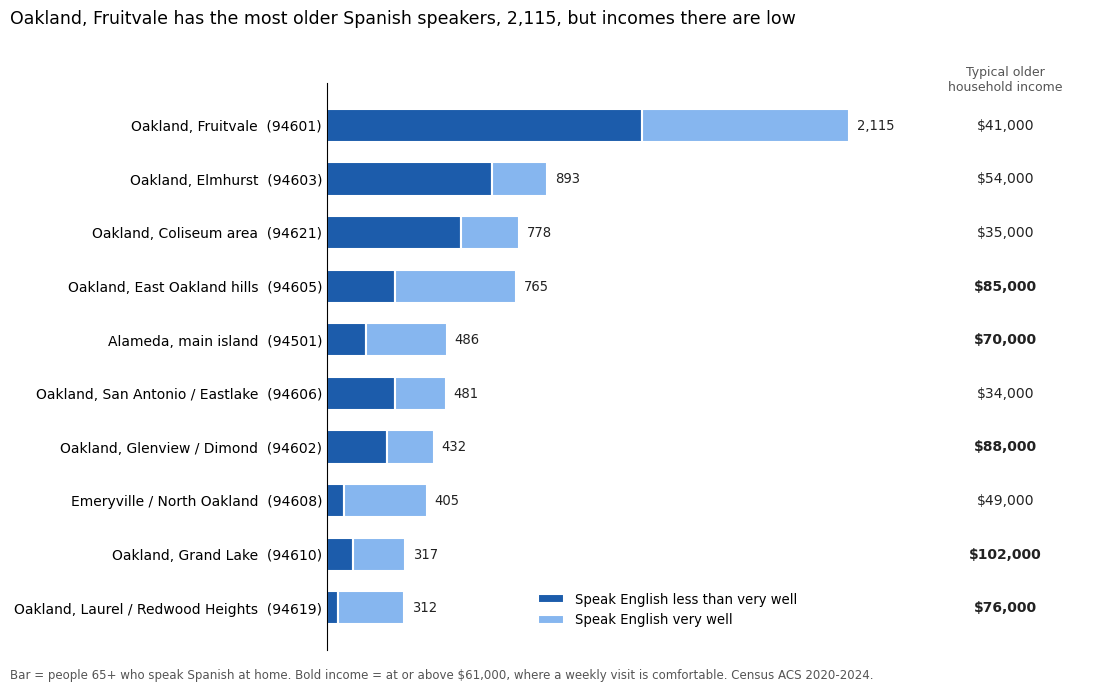

In [5]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

show = t.head(10)
ypos = list(range(len(show)))[::-1]   # first row at the top
labels = [f"{row['area']}  ({z})" for z, row in show.iterrows()]
DARK, LIGHT = "#1c5cab", "#86b6ef"    # one color: dark = limited English

fig, ax = plt.subplots(figsize=(11, 0.45 * len(show) + 2.4))
ax.barh(ypos, show["limited_english"], color=DARK, height=0.62, edgecolor="white", linewidth=1.5,
        label="Speak English less than very well")
ax.barh(ypos, show["english_very_well"], left=show["limited_english"], color=LIGHT, height=0.62,
        edgecolor="white", linewidth=1.5, label="Speak English very well")
longest = show["spanish_65plus"].max()
col_x = longest * 1.3
for y, (z, row) in zip(ypos, show.iterrows()):
    ax.text(row["spanish_65plus"] + longest * 0.015, y, f"{row['spanish_65plus']:,.0f}", va="center", fontsize=9.5, color="#222222")
    can_pay = row["typical_household_income"] >= INCOME_LINE
    ax.text(col_x, y, f"\\${round(row['typical_household_income'], -3):,.0f}", va="center", ha="center", fontsize=10,
            color="#222222", fontweight="bold" if can_pay else "normal")
ax.text(col_x, len(show) - 0.4, "Typical older\nhousehold income", va="bottom", ha="center", fontsize=9, color="#555555")
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, longest * 1.45)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
ax.legend(loc="lower center", bbox_to_anchor=(0.45, 0.02), frameon=False, fontsize=9.5)
top = show.index[0]
headline = f"{show.loc[top, 'area']} has the most older Spanish speakers, {show.loc[top, 'spanish_65plus']:,.0f}"
if show.loc[top, "typical_household_income"] < INCOME_LINE:
    headline += ", but incomes there are low"
fig.suptitle(headline, x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.01, f"Bar = people 65+ who speak Spanish at home. Bold income = at or above \\${round(INCOME_LINE, -3):,.0f}, "
         "where a weekly visit is comfortable. Census ACS 2020-2024.", fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 0.97))
fig.savefig(f"{OUT}/spanish_speakers.png", dpi=150)
t.round(3).to_csv(f"{OUT}/spanish_speakers.csv")
plt.show()

## 5. What I decided

- **Where being bilingual helps and clients can likely pay:** the East Oakland hills, Alameda's main island, Glenview / Dimond, Grand Lake and Laurel / Redwood Heights.
- **Where the need is large but budgets are tight:** Fruitvale, Elmhurst and the Coliseum area. These are not launch areas for now. Before I decide about them, I want to look beyond income at assets and savings.
- **How I will use Spanish in my marketing:** State that I am bilingual in English and Spanish in all my materials.

### Limits to remember
- The Census asks what language people speak at home, not which language they want a helper to speak.
- Income here describes all older households in an area. Spanish-speaking households may earn more or less than that, and the Census does not publish it for ZIP codes.
- An adult child often arranges and pays for a parent's help, so a parent's income is not the whole picture.
- Counts for small groups in small ZIP codes are rough. A zero can mean "too few to measure", not "none".